In [1]:
import os
os.chdir("../")
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from burgers.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 150,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

In [3]:
# data = jnp.load("data/burgers/burgers_solutions.npz")
# x = data["x"]
# y = data["y"]
# t = data["times"]
# solutions = data["solutions"]  # (num_times, num_points)
# xx, yy = jnp.meshgrid(x, y, indexing="xy") # (H, W)


# time_idxs = [0, 1, 4, 6, 8, 10]
# fig, axes = plt.subplots(8, 6, figsize=(12, 16), sharex=True, sharey=True)
# for example_id in range(8):
#     for i, time_idx in enumerate(time_idxs):
#         ax = axes[example_id, i]
#         ax.contourf(xx, yy, solutions[example_id, time_idx, 1], levels=50, cmap="RdBu_r")
#         if example_id == 0:
#             # ax.set_title(f"t = {t[time_idx]:.2f}", pad=5)
#             ax.text(0.5, 1.05, f"t = {t[time_idx]:.2f}", va="bottom", ha="center", transform=ax.transAxes)
#         if i == 0:
#             # ax.set_ylabel(f"Example {example_id + 1}", rotation=0, labelpad=15)
#             ax.text(-0.05, 0.5, f"Example {example_id + 1}", va="center", ha="right", rotation=90, transform=ax.transAxes)
#         ax.set_axis_off()
#         ax.set_aspect("equal")
# fig.tight_layout()

In [4]:
# fig, axes = plt.subplots(2, 4, figsize=(6, 3))
# vmin, vmax = jnp.min(solutions[:, 0, 0]), jnp.max(solutions[:, 0, 0])
# axes = axes.flatten()
# B = solutions.shape[0]
# for b in range(B):
#     ax = axes[b]
#     ax.pcolormesh(xx, yy, solutions[b, 0, 0], cmap="RdBu_r", 
#                   vmin=vmin, vmax=vmax, rasterized=True, shading="gouraud")
#     ax.set_axis_off()
#     ax.set_aspect("equal")
# # put a colorbar on the right of figure
# cbar_ax = fig.add_axes([1.01, 0.05, 0.02, 0.9])
# norm = plt.Normalize(vmin=vmin, vmax=vmax)
# sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
# sm.set_array([])
# fig.colorbar(sm, cax=cbar_ax)
# cbar_ax.set_title("Velocity", pad=5)
# fig.tight_layout()

# # fig.savefig("./figures/burgers_test_data_overview.pdf", bbox_inches="tight", dpi=300)

In [5]:
from burgers.periodic_cvit import PeriodicCViT

key = jax.random.PRNGKey(0)
model_params = configs.model_params
model_skeleton = PeriodicCViT(
    key,
    lx=configs.lx,
    ly=configs.ly,
    **model_params,
)

weight = "/root/autodl-tmp/tf-logs/burgers/cvit/sota-nofilm/model_epoch_15000.eqx"
# weight = "/root/autodl-tmp/tf-logs/burgers/cvit/sota-film/model_epoch_15000.eqx"
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [6]:
data_dir = configs.data_dir
target_ts = configs.target_ts
# target_ts =[0.0, 0.1, 0.3, 0.6, 1.0]
Lc = configs.Lc
Tc = configs.Tc
data = jnp.load(f"{data_dir}/burgers_solutions.npz")
x = data["x"]  # (W,)
y = data["y"]  # (H,)
# x = jnp.linspace(0, configs.lx, configs.Nx, endpoint=False)
# y = jnp.linspace(0, configs.ly, configs.Ny, endpoint=False)
fft_times = data["times"]  # (T,)
ref_sols = data["solutions"]    
idxs = jnp.array(
    [jnp.argmin(jnp.abs(fft_times - t)) for t in target_ts]
)
ref_sols = ref_sols[:, idxs, ...] # B, T, C, H, W

B, T, C, H, W = ref_sols.shape
us = ref_sols[:, 0, ...] # B, C=2, H, W
xx, yy = jnp.meshgrid(x, y, indexing="xy")  # (H, W)
xx = xx / Lc
yy = yy / Lc
x_pde = jnp.stack([
    xx.reshape(-1),
    yy.reshape(-1),
], axis=-1)  # (Nx*Ny, 2)

def fwd_fn(carry, t):
    t_pde = jnp.full((x_pde.shape[0], 1), t)
    sol = jax.vmap(
        model, in_axes=(0, None, None)
    )(
        us, x_pde, t_pde
    ) # B, Nx*Ny, C
    return carry, sol

_, sols = jax.lax.scan(
    fwd_fn,
    None,
    jnp.array(target_ts) / Tc,
) # sols: T, B, H*W, C=2

sols = rearrange(
    sols, "t b (h w) c -> b t c h w", h=int(H), w=int(W)
)
# 如果前面的Indexing是"ij"，这里就是 "t b (w h) c -> b t c h w"

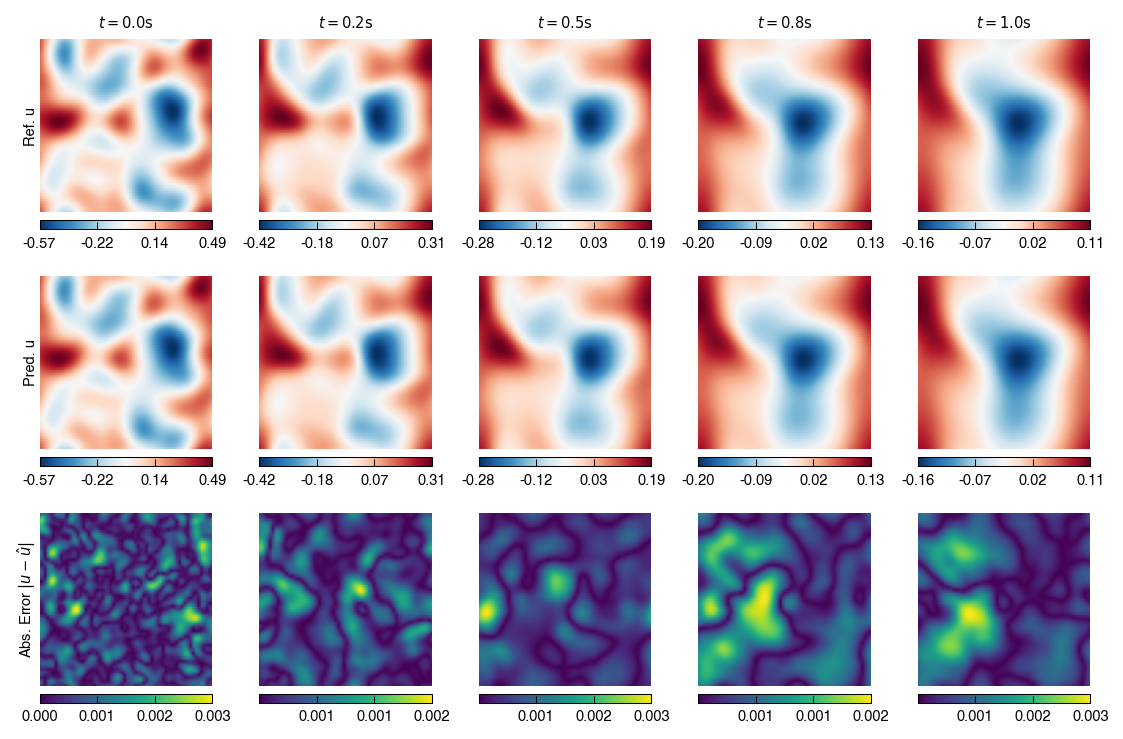

In [7]:
batch_th = 2
channel_th = 0  # 0: u, 1: v
fig, axes = plt.subplots(
    3,
    len(target_ts),
    figsize=(1.5 * len(target_ts), 5),
    subplot_kw={
        "aspect": "equal",
    },
)
notation = "u" if channel_th == 0 else "v"
for i, tic in enumerate(target_ts):
    ax = axes[0, i]
    ax.set_axis_off()
    vmin = jnp.min(ref_sols[batch_th, i, channel_th, :, :])
    vmax = jnp.max(ref_sols[batch_th, i, channel_th, :, :])
    ref_ax = ax.pcolormesh(
        xx, yy,
        ref_sols[batch_th, i, channel_th, :, :],
        cmap="RdBu_r",
        rasterized=True,
        shading="gouraud",
        vmin=vmin,
        vmax=vmax,
    )

    fig.colorbar(
        ref_ax, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
        format="%.2f", ticks=jnp.linspace(vmin, vmax, num=4)
    )
    if i == 0:
        ax.text(
            -0.01,
            0.5,
            f"Ref. {notation}",
            rotation=90,
            va="center",
            ha="right",
            transform=ax.transAxes,
        )
    ax.text(
        0.5,
        1.05,
        rf"$t={tic:.1f}\mathrm{{s}}$",
        va="bottom",
        ha="center",
        transform=ax.transAxes,
    )
    


    ax = axes[1, i]
    ax.set_axis_off() 
    pred_ax = ax.pcolormesh(
        xx, yy,
        sols[batch_th, i, channel_th, :, :],
        cmap="RdBu_r",
        rasterized=True,
        shading="gouraud",
        vmin=vmin,
        vmax=vmax,
    )
    fig.colorbar(
        pred_ax, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
        format="%.2f", ticks=jnp.linspace(vmin, vmax, num=4)
    )

    if i == 0:
        ax.text(
            -0.01,
            0.5,
            f"Pred. {notation}",
            rotation=90,
            va="center",
            ha="right",
            transform=ax.transAxes,
        )
        

    
    ax = axes[2, i]
    ax.set_axis_off()
    diff = jnp.abs(
        ref_sols[batch_th, i, channel_th, :, :]
        - sols[batch_th, i, channel_th, :, :]
    )
    diff_cont = ax.pcolormesh(
        xx, yy,
        diff,
        cmap="viridis",
        rasterized=True,
        shading="gouraud"
    )
    
    if i == 0:
        ax.text(
            -0.01,
            0.5,
            r"Abs. Error $|u - \hat{u}|$",
            rotation=90,
            va="center",
            ha="right",
            transform=ax.transAxes,
        )
        
    colorbar = fig.colorbar(
        diff_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
        format="%.3f", ticks=jnp.linspace(0, jnp.max(diff), num=4)
    )
    
total_l2 = jnp.sqrt(jnp.sum((ref_sols - sols) ** 2, axis=(1, 3, 4))) / jnp.sqrt(
    jnp.sum(ref_sols**2, axis=(1, 3, 4))
)
total_l2 = jnp.mean(total_l2)
fig.tight_layout()
# fig.subplots_adjust(
#     left=0.03, right=0.97, top=0.95, bottom=0.03, hspace=0.1, wspace=0.1
# )
# fig.suptitle(
#     f"Exam. {batch_th}, Var. {notation}, Rel. L2 Error: {total_l2:.2e}",
#     y=1.02,
# )
# fig.savefig("./figures/burgers_solution_field.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
# fig.savefig("./figures/burgers_solution_field.pdf", dpi=300, bbox_inches="tight", pad_inches=0.03)

## 绘制涡量图

In [8]:
# 绘制涡量图
# reference: 通过 fft 在频域求解得到的数值解，具有较高的精度，可以视为近似的真解
def compute_vorticity(sol, x, y):
    # sol: C, H, W
    # omega = dv/dx - du/dy
    sol = jnp.transpose(sol, (0, 2, 1))  # C, W, H
    kx = jnp.fft.fftfreq(sol.shape[1], d=(x[1] - x[0])) * 2 * jnp.pi  # (W,)
    ky = jnp.fft.fftfreq(sol.shape[2], d=(y[1] - y[0])) * 2 * jnp.pi  # (H,)
    kx, ky = jnp.meshgrid(kx, ky, indexing="ij")  # (W, H)
    u_hat = jnp.fft.fft2(sol[0, ...])  # (W, H)
    v_hat = jnp.fft.fft2(sol[1, ...])  # (W, H)
    vorticity_hat = 1j * (kx * v_hat - ky * u_hat)  # (W, H)
    vorticity = jnp.fft.ifft2(vorticity_hat).real  # (W, H)
    vorticity = jnp.transpose(vorticity, (1, 0))  # H, W
    return vorticity

def compute_vorticity_autodiff(u, x, t):
    # u: input function, (C, H, W)
    # x: spatial coordinates, (N_query, 2)
    # t: time coordinate, (N_query,1)
    
    enc_out = model.encoder(u) # N_patches, emb_dim
    def sol_single(xi, ti):
        # xi: (2,), ti: (1,)
        sol = model.decoder(enc_out, xi[None, :], ti[None, :]) # 1, C=2
        return sol[0, :] # C
    
    def compute_derivative(xi, ti):
        # xi: (2,), ti: (1,)
        sol = sol_single(xi, ti) # C
        grad_x = jax.jacrev(sol_single, argnums=0)(xi, ti) # C, 2
        u_y = grad_x[0, 1] # du/dy
        v_x = grad_x[1, 0] # dv/dx
        vorticity = v_x - u_y
        return vorticity
    
    vorticity_fn = jax.vmap(compute_derivative, in_axes=(0,0))
    vorticity = vorticity_fn(x, t) # N_query
    return vorticity


def fwd_virt_fn(carry, t):
    t_pde = jnp.full((x_pde.shape[0], 1), t)
    vorticity = jax.vmap(
        compute_vorticity_autodiff, in_axes=(0, None, None)
    )(us, x_pde, t_pde) # B, Nx*Ny
    return carry, vorticity

_, vorticity_sol = jax.lax.scan(
    fwd_virt_fn,
    None,
    jnp.array(target_ts) / Tc,
) # vorticity_sol: T, B, H*W

vorticity_sol = rearrange(
    vorticity_sol, "t b (h w) -> b t h w", h=int(H), w=int(W)
)
vorticity_ref = jax.vmap(
    jax.vmap(
        compute_vorticity, in_axes=(0, None, None)
    ), in_axes=(0, None, None)
)(ref_sols, x, y) # B, T, H, W

vorticity_sol.shape, vorticity_ref.shape

((8, 5, 64, 64), (8, 5, 64, 64))

Exam. 2, Var. Vorticity, Rel. L2 Error: 1.22e-02


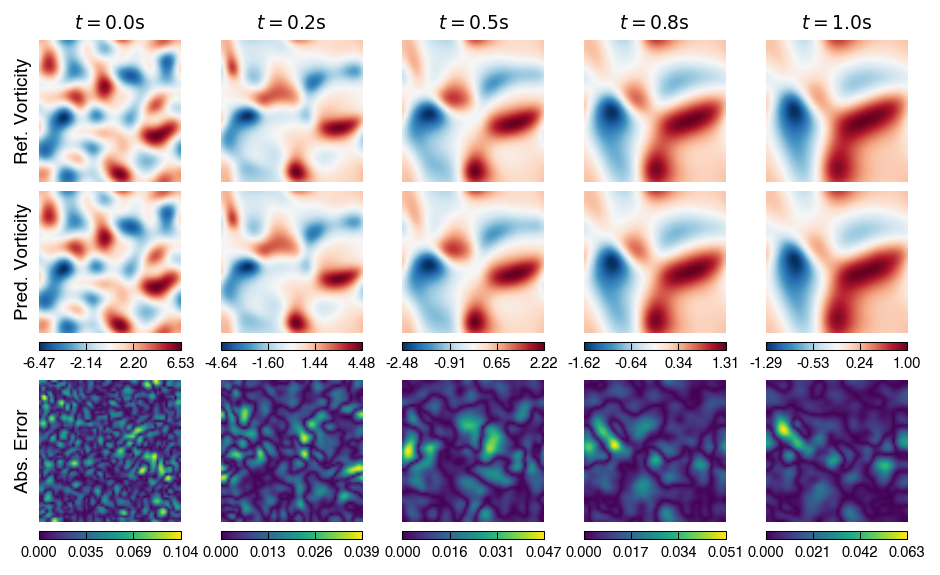

In [9]:

from matplotlib import gridspec
batch_th = 2
fig = plt.figure(figsize=(7.5, 4.5))
gs = gridspec.GridSpec(5, len(target_ts), figure=fig, wspace=0.25, hspace=0.1,
                       height_ratios=[1, 1, 0.2, 1, 0.2])


for i, tic in enumerate(target_ts):
    vmin = jnp.min(vorticity_ref[batch_th, i, :, :])
    vmax = jnp.max(vorticity_ref[batch_th, i, :, :])
    
    ax = fig.add_subplot(gs[0, i])
    ax.set_axis_off()
    ref_ax = ax.imshow(
        vorticity_ref[batch_th, i, :, :], 
            extent=(x.min(), x.max(), y.min(), y.max()),
            origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax,
            interpolation="bilinear", rasterized=True,)
    if i == 0:
        ax.text(-0.05, 0.5, "Ref. Vorticity", rotation=90, va="center", ha="right", transform=ax.transAxes, fontsize=9)
    ax.text(0.5, 1.05, rf"$t={tic:.1f}\mathrm{{s}}$", va="bottom", ha="center", transform=ax.transAxes, fontsize=9)
    
    ax = fig.add_subplot(gs[1, i])
    ax.set_axis_off()

    pred_ax = ax.imshow(
        vorticity_sol[batch_th, i, :, :], 
            extent=(x.min(), x.max(), y.min(), y.max()),
            origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax,
            interpolation="bilinear", rasterized=True,)
    if i == 0:
        ax.text(-0.05, 0.5, "Pred. Vorticity", rotation=90, va="center", ha="right", transform=ax.transAxes, fontsize=9)

    
    # cbar_ax = fig.add_subplot(gs[2, i])
    pos = ax.get_position()
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.025, pos.width, 0.012])
    
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", format="%.2f", ticks=jnp.linspace(vmin, vmax, num=4))
    # cbar.set_label("Vorticity", fontsize=9)
    
    ax = fig.add_subplot(gs[3, i])
    error = jnp.abs(vorticity_ref[batch_th, i, :, :] - vorticity_sol[batch_th, i, :, :])
    error_ax = ax.imshow(
        error,
        extent=(x.min(), x.max(), y.min(), y.max()),
        origin="lower", cmap="viridis", vmin=0, vmax=jnp.max(error),
        interpolation="bilinear", rasterized=True,
    )
    if i == 0:
        ax.text(-0.05, 0.5, r"Abs. Error",
                rotation=90, va="center", ha="right", transform=ax.transAxes, fontsize=9)
    ax.set_axis_off()
    
    # cbar_ax = fig.add_subplot(gs[4, i])
    pos = ax.get_position()
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.025, pos.width, 0.012])
    
    norm = plt.Normalize(vmin=0, vmax=jnp.max(error))
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", format="%.3f", ticks=jnp.linspace(0, jnp.max(error), num=4))
    

l2 = jnp.sqrt(jnp.sum((vorticity_ref[batch_th] - vorticity_sol[batch_th]) ** 2)) / jnp.sqrt(jnp.sum(vorticity_ref[batch_th] ** 2))
# fig.suptitle(f"Exam. {batch_th}, Var. Vorticity, Rel. L2 Error: {l2_erro:.2e}", y=1.02,
print(f"Exam. {batch_th}, Var. Vorticity, Rel. L2 Error: {l2:.2e}")
# fig.savefig("./figures/burgers_vorticity_field.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
# fig.savefig("./figures/burgers_vorticity_field.pdf", dpi=300, bbox_inches="tight", pad_inches=0.03)

## CViT预测不同sample

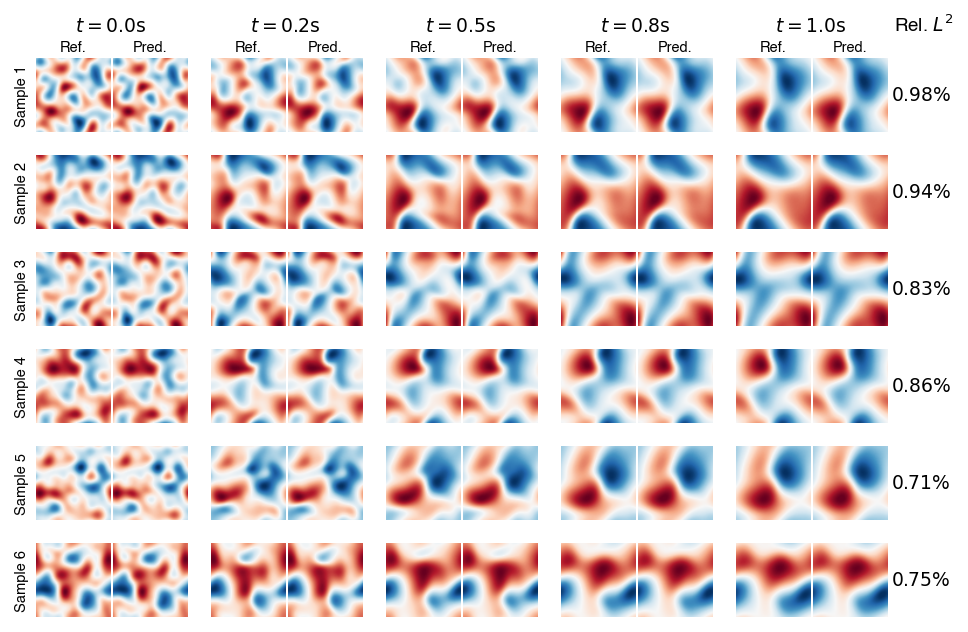

In [10]:
from matplotlib import gridspec
num_samples = 6
# randomly select num_samples examples from batch dimension
sample_idxs = jax.random.choice(key, B, shape=(num_samples,), replace=False)
fig = plt.figure(figsize=(7.5, 5))
gs = gridspec.GridSpec(num_samples, len(target_ts)*3, figure=fig, wspace=0.05, hspace=0.05,
                       width_ratios=[1, 1, 0.25] * len(target_ts))

channel_th = 0  # 0: u, 1: v
for row, batch_th in enumerate(sample_idxs):
    for col, tic in enumerate(target_ts):
        ax = fig.add_subplot(gs[row, col*3])
        ax.set_axis_off()
        vmin = jnp.min(ref_sols[batch_th, col, channel_th, :, :])
        vmax = jnp.max(ref_sols[batch_th, col, channel_th, :, :])
        ref_ax = ax.imshow(
            ref_sols[batch_th, col, channel_th, :, :],
            extent=(x.min(), x.max(), y.min(), y.max()),
            origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax,
            interpolation="bilinear", rasterized=True,
        )
        
        if row == 0:
            ax.text(1.0, 1.3, rf"$t={tic:.1f}\mathrm{{s}}$", va="bottom", ha="center", transform=ax.transAxes, fontsize=9)
            ax.text(0.5, 1.05, "Ref.", va="bottom", ha="center", transform=ax.transAxes)
        
        # pos = ax.get_position()
        # cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.024, pos.width, 0.01])
        # norm = plt.Normalize(vmin=vmin, vmax=vmax)
        # sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
        # sm.set_array([])
        # fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", format="%.2f", ticks=jnp.linspace(vmin, vmax, num=3),)
            
        if col == 0:
            ax.text(-0.1, 0.5, f"Sample {row+1}", rotation=90, va="center", ha="right", transform=ax.transAxes)
            
        ax = fig.add_subplot(gs[row, col*3+1])
        ax.set_axis_off()
        pred_ax = ax.imshow(
            sols[batch_th, col, channel_th, :, :],
            extent=(x.min(), x.max(), y.min(), y.max()),
            origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax,
            interpolation="bilinear", rasterized=True,
        )
        if row == 0:
            ax.text(0.5, 1.05, "Pred.", va="bottom", ha="center", transform=ax.transAxes)
            
        if col == len(target_ts) - 1:
            l2_error = jnp.linalg.norm(ref_sols[batch_th, :, channel_th, :, :] - sols[batch_th, :, channel_th, :, :]) / jnp.linalg.norm(ref_sols[batch_th, :, channel_th, :, :])
            l2_error_perc = l2_error * 100
            ax.text(1.05, 0.5, fr"${l2_error_perc:.2f}\%$", va="center", ha="left", transform=ax.transAxes, fontsize=9)
            
            if row == 0:
                ax.text(1.5, 1.3, "Rel. $L^2$", va="bottom", ha="center", transform=ax.transAxes, fontsize=9)
            
        # l2_error = jnp.linalg.norm(ref_sols[batch_th, col, channel_th, :, :] - sols[batch_th, col, channel_th, :, :]) / jnp.linalg.norm(ref_sols[batch_th, col, channel_th, :, :])
        # l2_error_perc = l2_error * 100
        # ax.text(0., -0.05, fr"Rel. $L^2={l2_error_perc:.2f}\%$", va="top", ha="center", transform=ax.transAxes)

# fig.savefig("./figures/burgers_solution_field_samples.pdf", dpi=300, bbox_inches="tight", pad_inches=0.01)

In [11]:
# epochs = jnp.arange(0, 15001, 500)
# l2_logs = []

# def fwd_fn(model, carry, t):
#     t_pde = jnp.full((x_pde.shape[0], 1), t)
#     sol = jax.vmap(
#         model, in_axes=(0, None, None)
#     )(
#         us, x_pde, t_pde
#     ) # B, Nx*Ny, C
#     return carry, sol

# for epoch in epochs:
#     weight = f"/root/autodl-tmp/tf-logs/burgers/cvit/sota-nofilm/model_epoch_{epoch}.eqx"
#     model = eqx.tree_deserialise_leaves(weight, model_skeleton)
    
#     _, sols = jax.lax.scan(
#         partial(fwd_fn, model),
#         None,
#         jnp.array(target_ts) / Tc,
#     ) # sols: T, B, H*W, C=2

#     sols = rearrange(
#         sols, "t b (h w) c -> b t c h w", h=int(H), w=int(W)
#     )
    
#     total_l2 = jnp.sqrt(jnp.sum((ref_sols - sols) ** 2, axis=(1, 3, 4))) / jnp.sqrt(
#         jnp.sum(ref_sols**2, axis=(1, 3, 4))
#     )
#     total_l2 = jnp.mean(total_l2)
#     l2_logs.append(total_l2)

In [12]:
# from models.utils import smooth_loss_log_gaussian

# mean, lower, upper = smooth_loss_log_gaussian(jnp.array(l2_logs), 
#                                               sigma=2,
#                                               n_boot=500,)

# fig, ax = plt.subplots(figsize=(3, 2))
# # ax.plot(epochs, l2_logs, marker="o")
# ax.plot(epochs, mean, label="Mean", color="C0",)
# ax.fill_between(epochs, lower, upper, alpha=0.2, label="95% CI", color="C0")
# ax.set_yscale("log")
# ax.set_xlabel("Training Epochs")
# ax.set_ylabel("Relative L2 Error")
# print("Minimum Relative L2 Error:", jnp.min(jnp.array(l2_logs)))
# # fig.savefig("./figures/burgers_test_l2_convergence.png", dpi=300, bbox_inches="tight", pad_inches=0.0)
# # fig.savefig("./figures/burgers_test_l2_convergence.pdf", dpi=300, bbox_inches="tight", pad_inches=0.0)

In [13]:
# import pandas as pd
# df = pd.read_csv("./burgers/data_vs_physics.txt", sep=",")
# fig, ax = plt.subplots(figsize=(3.0, 2.4))
# cvit_err = 7.744e-3
# xs = df["num_labeled_data_seriers"]
# ax.axhline(y=cvit_err, label="Pure physics", linestyle="--", color="C0", )
# ax.plot(xs, df["pure_data"]/100, 
#         marker="o", label="Pure data", color="C1",
#         markersize=5, markeredgecolor="white", markeredgewidth=0.5)
# ax.plot(xs, df["physics_on_data"]/100, 
#         marker="o", label="Physics on labeled data", 
#         color="C2", 
#         markersize=5, markeredgecolor="white", markeredgewidth=0.5)
# ax.plot(xs, df["hybrid_physics_data"]/100, 
#         marker="o", label="Physics on unlabeled data", 
#         color="C3",
#         markersize=5, markeredgecolor="white", markeredgewidth=0.5)
# # ax.text(50, cvit_err, "Infinite samples for pure physics", va="bottom", ha="left")
# ax.set_yscale("log")
# ax.set_xscale("log", base=2)
# # ax.legend(bbox_to_anchor=(0.1, 0.1), loc="lower left")
# # ax.set_ylim(5e-4, 1e0)
# ax.legend(ncol=2, bbox_to_anchor=(0.5, 1.01), loc="lower center", )
# ax.set_xlabel("Number of labeled data series")
# ax.set_ylabel("Rel. $L_2$ Error")
# fig.tight_layout()
# fig.savefig("./figures/burgers_data_vs_physics.png", dpi=300, bbox_inches="tight", pad_inches=0.01)
# fig.savefig("./figures/burgers_data_vs_physics.pdf", dpi=300, bbox_inches="tight", pad_inches=0.01)

In [14]:
# from models.utils import smooth_loss_log_gaussian

# paths = [
#     "training_logs/burgers/run-burgers_cvit_sota-nofilm-tag-eval_l2_error.csv",
#     "training_logs/burgers/run-burgers_cvit_ablation_adam-tag-eval_l2_error.csv"
# ]

# tags = ["soap", "adam"]


# final_step = 15000

# fig, ax = plt.subplots(figsize=(3, 2))
# for i, (path, tag) in enumerate(zip(paths, tags)):
#     df = pd.read_csv(path)
#     df = df[df["Step"] <= final_step]
#     val = df["Value"]
#     step = df["Step"]
#     # ax.plot(df["Step"], df["Value"], label=tag)
#     mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.0, n_boot=1000)
#     ax.plot(step, mean, label=tag)
#     ax.fill_between(step, lower, upper, alpha=0.2)
# ax.set(xlabel="Step", ylabel="Ral. $L_2$ Error", yscale="log")
# ax.legend()
# plt.tight_layout()
# plt.show()

## 不同model对比

In [15]:
from burgers.periodic_cvit import PeriodicCViT
from burgers.periodic_deeponet import PeriodicDeepONet
from models.fno import FNO

from burgers.configs.train_cvit import Config as cvit_configs
from burgers.configs.train_deeponet import Config as deeponet_configs
from burgers.configs.train_fno import Config as fno_configs

model_info = [
    {
        "name": "CViT",
        "model": PeriodicCViT,
        "config": cvit_configs,
        "weight": "/root/autodl-tmp/tf-logs/burgers/cvit/sota-nofilm/model_epoch_15000.eqx",
    },
    {
        "name": "DeepONet",
        "model": PeriodicDeepONet,
        "config": deeponet_configs,
        "weight": "/root/autodl-tmp/tf-logs/burgers/deeponet/baseline-0219/model_epoch_15000.eqx",
    },
    {
        "name": "FNO",
        "model": FNO,
        "config": fno_configs,
        # "weight": "/root/autodl-tmp/tf-logs/burgers/fno/baseline/model_epoch_2000.eqx",
        "weight": "/root/autodl-tmp/tf-logs/burgers/fno/baseline-2/model_epoch_13000.eqx",
    },
]

In [16]:
data_dir = configs.data_dir
target_ts = configs.target_ts
# target_ts =[0.0, 0.1, 0.3, 0.6, 1.0]
Lc = configs.Lc
Tc = configs.Tc
# data = jnp.load(f"{data_dir}/burgers_solutions.npz")
data = jnp.load(f"{data_dir}/burgers_training.npz")
x = data["x"]  # (W,)
y = data["y"]  # (H,)
# x = jnp.linspace(0, configs.lx, configs.Nx, endpoint=False)
# y = jnp.linspace(0, configs.ly, configs.Ny, endpoint=False)
fft_times = data["times"]  # (T,)
ref_sols = data["solutions"]    
idxs = jnp.array(
    [jnp.argmin(jnp.abs(fft_times - t)) for t in target_ts]
)
ref_sols = ref_sols[:, idxs, ...] # B, T, C, H, W

B, T, C, H, W = ref_sols.shape
us = ref_sols[:, 0, ...] # B, C=2, H, W
xx, yy = jnp.meshgrid(x, y, indexing="xy")  # (H, W)
xx = xx / Lc
yy = yy / Lc
x_pde = jnp.stack([
    xx.reshape(-1),
    yy.reshape(-1),
], axis=-1)  # (Nx*Ny, 2)



In [17]:
us.shape

(100, 2, 64, 64)

CViT Rel. L2 Error: 7.69e-03 ± 1.14e-03, n=100
DeepONet Rel. L2 Error: 3.45e-01 ± 2.54e-02, n=100
FNO Rel. L2 Error: 9.67e-02 ± 1.84e-02, n=100


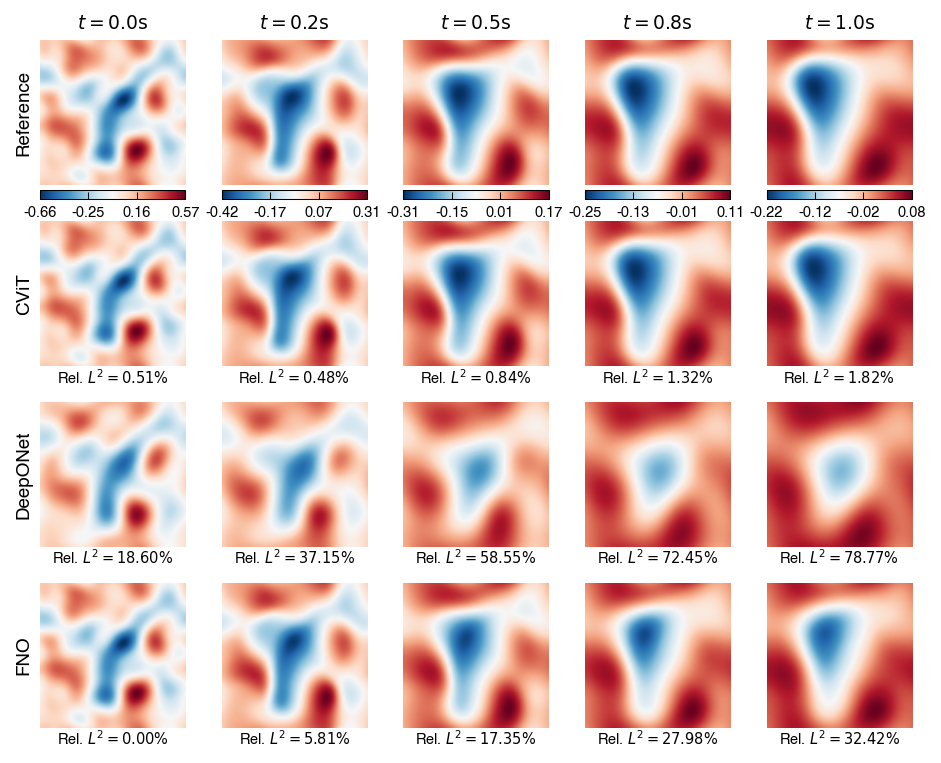

In [18]:

# fig, axes = plt.subplots(4, len(target_ts), figsize=(7., 6), 
#                          sharex=True, sharey=True, subplot_kw={"aspect": "equal"})
# 4 rows for reference, cvit, deeponet and fno
from matplotlib import gridspec
batch_th = 2
fig = plt.figure(figsize=(7.5, 6))
gs = gridspec.GridSpec(4, len(target_ts), figure=fig, wspace=0.25, hspace=0.2,
                       height_ratios=[1, 1, 1, 1,]) # last row for colorbar

max_vals = jnp.max(ref_sols[batch_th, :, channel_th, :, :], axis=(1, 2)) # shape (T,)
min_vals = jnp.min(ref_sols[batch_th, :, channel_th, :, :], axis=(1, 2)) # shape (T,)
for col in range(len(target_ts)):
    # ax = axes[0, col]
    ax = fig.add_subplot(gs[0, col])
    ref_contourf = ax.imshow(
        ref_sols[batch_th, col, channel_th, ], 
        extent=(x.min(), x.max(), y.min(), y.max()),
        origin="lower",
        cmap="RdBu_r",
        vmin=min_vals[col],
        vmax=max_vals[col],
        interpolation="bilinear",
        rasterized=True,
    )
    ax.set_axis_off()
    
    ax.text(0.5, 1.05, rf"$t = {target_ts[col]:.1f}\mathrm{{s}}$", va="bottom", ha="center", transform=ax.transAxes, fontsize=9)
    if col == 0:
        ax.text(-0.05, 0.5, "Reference", rotation=90, va="center", ha="right", transform=ax.transAxes, fontsize=9)
        
    # add an extra ax to show colorbar for reference solution
    current_position = ax.get_position()
    cax = fig.add_axes([
        current_position.x0,
        current_position.y0 - 0.015,
        current_position.width,
        0.01,
    ])
    norm = plt.Normalize(vmin=min_vals[col], vmax=max_vals[col])
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", format="%.2f", 
                        ticks=jnp.linspace(min_vals[col], max_vals[col], num=4))

for row, info in enumerate(model_info):
    model_cls = info["model"]
    config_cls = info["config"]
    weight_path = info["weight"]
    name = info["name"]
    # if name.lower() == "fno":
    #     config_cls.model_params.update({
    #         "width": 64,
    #         "modes_x": 16,
    #         "modes_y": 16,
    #         "out_channels": 2
    #     })

    key = jax.random.PRNGKey(0)
    model_skeleton = model_cls(
        key,
        **config_cls.model_params,
    )
    
    model = eqx.tree_deserialise_leaves(weight_path, model_skeleton)

    if name.lower() == "fno":
        # fno predict the whole trajectory at once, so we need to reshape the input and output
        # pred_times = jnp.linspace(0, 1.0, sols.shape[2])
        us_fno = repeat(us, "b c h w -> b c w h") # fno uses `W, H` order
        if us_fno.shape[0] <= 20:
            fno_full_sols = jax.vmap(model)(us_fno)
            sols = jnp.concatenate([us_fno[:, :, None, :, :], fno_full_sols], axis=2) # B, C, T+1, W, H
        else:
            # we use mini-batch to predict the whole trajectory to avoid OOM
            batch_size = 20
            num_batches = int(jnp.ceil(us_fno.shape[0] / batch_size))
            sols_list = []
            for i in range(num_batches):
                us_batch = us_fno[i*batch_size:(i+1)*batch_size]
                fno_full_sols_batch = jax.vmap(model)(us_batch)
                sols_batch = jnp.concatenate([us_batch[:, :, None, :, :], fno_full_sols_batch], axis=2) # B, C, T+1, W, H
                sols_list.append(sols_batch)
            sols = jnp.concatenate(sols_list, axis=0) # B, C, T+1, W, H
        
        pred_times = jnp.linspace(0, 1.0, sols.shape[2]) * Tc # (T+1,)
        pred_idxs = jnp.array(
            [jnp.argmin(jnp.abs(pred_times - t)) for t in target_ts]
        )
        sols = sols[:, :, pred_idxs, :, :] # B, C, T, W, H
        
        sols = rearrange(
            sols, "b c t w h -> b t c h w", h=int(H), w=int(W)
        )
    else:
        # cvit and deeponet predict at arbitrary time steps, so we can directly use fwd_fn
        def fwd_fn(carry, t):
            t_pde = jnp.full((x_pde.shape[0], 1), t)
            sol = jax.vmap(
                model, in_axes=(0, None, None)
            )(
                us, x_pde, t_pde
            ) # B, Nx*Ny, C
            return carry, sol
        
        _, sols = jax.lax.scan(
            fwd_fn,
            None,
            jnp.array(target_ts) / Tc,
        ) # sols: T, B, H*W, C=2
        sols = rearrange(
            sols, "t b (h w) c -> b t c h w", h=int(H), w=int(W)
        )
        
    l2_errors = jnp.sqrt(jnp.mean((sols - ref_sols) ** 2, axis=[1, 3, 4])) / jnp.sqrt(jnp.mean(ref_sols ** 2, axis=[1, 3, 4])) # B, C
    l2_errors = jnp.mean(l2_errors, axis=-1) # B
    print(f"{name} Rel. L2 Error: {l2_errors.mean():.2e} ± {l2_errors.std():.2e}, n={l2_errors.shape[0]}")
    
    for col in range(len(target_ts)):
        # ax = axes[row+1, col]
        ax = fig.add_subplot(gs[row+1, col])
        ax.set_axis_off()
        # pred_ax = ax.pcolormesh(
        #     xx, yy,
        #     sols[batch_th, col, channel_th, :, :],
        #     cmap="RdBu_r",
        #     rasterized=True,
        #     shading="nearest",
        #     vmin=min_vals[col],
        #     vmax=max_vals[col],
        # )
        pred_ax = ax.imshow(
            sols[batch_th, col, channel_th, :, :],
            extent=(x.min(), x.max(), y.min(), y.max()),
            origin="lower",
            cmap="RdBu_r",
            vmin=min_vals[col],
            vmax=max_vals[col],
            interpolation="bilinear",
            rasterized=True,
        )
        l2_error = jnp.linalg.norm(
            ref_sols[batch_th, col, channel_th, :, :] - sols[batch_th, col, channel_th, :, :]
        ) / jnp.linalg.norm(ref_sols[batch_th, col, channel_th, :, :])
        # l2_error_sci_format =
        # format 3.232423e-03 to 0.323 %
        l2_error_percent = l2_error * 100
        
        ax.text(0.5, -0.01, fr"Rel. $L^2 = {l2_error_percent:.2f}\%$", va="top", ha="center", transform=ax.transAxes)
        # ax.text(0.5, -0.1, f"L2 Error: {l2_error:.2e}", va="top", ha="center", transform=ax.transAxes)

        if col == 0:
            ax.text(-0.05, 0.5, name, rotation=90, va="center", ha="right", transform=ax.transAxes, fontsize=9)
            
# fig.savefig("./figures/burgers_solution_all_models.pdf", dpi=300, bbox_inches="tight", pad_inches=0.01)